# 案例 05 · 全球机场适配性：C919（代理机型）能去哪些机场？

**这个案例回答什么？**
- 满载的窄体机（A320neo 级代理）在高温/高海拔机场要不要减载？减多少？
- 中国的高高原机场（稻城/邦达/康定/阿里……）哪座最紧张？
- 全球 86,000 个机场里，这个级别机型覆盖了多少？

**方法**：重量参数化的场长模型（TOFL 与重量² 成正比）反解出"跑道允许的最大起飞重量"，
减载直接落在业载上。分类：**ok**（满载可用）/ **reduced**（减载可用）/ **infeasible**（跑道不足）。

**诚实话**
- 场长为启发式公式（无障碍物/净空/襟翼/V1），着陆距离按 0.65 × 起飞粗估；
- 温度用假设（ISA+15 热天），OurAirports 数据集没有气候数据；
- 场长基准值（海平面 2,000 m @ MTOW）偏乐观，**绝对余量偏大，相对排名可靠**；
- 所有结果仅供学习演示。数据：OurAirports 全量 86k（公有领域）。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from routelab.adaptability import adapt_for_airport, plateau_airports, scan_region
from routelab.airports import AirportDB
from routelab.performance import ProxyAircraft

db = AirportDB()
AC = ProxyAircraft()
print(f"机场总数: {len(db.all()):,}")

# 中国高高原（>= 3500 ft）
plateau = plateau_airports(db, min_elevation_ft=3500.0, country="CN")
print(f"中国 >= 3500 ft 机场: {len(plateau)} 座")

机场总数: 86,151
中国 >= 3500 ft 机场: 121 座


## 1. 中国高高原专项：每一座都咬人

In [2]:
rows = []
for f in plateau:
    if f["runway_m"] < 2000:   # 过滤无跑道数据/直升机坪
        continue
    r = adapt_for_airport(db, AC, f["ident"], airport=db.get(f["ident"]))
    rows.append({
        "机场": f"{f['ident']} {f['iata']}", "名称": f["name"].title()[:34],
        "标高 ft": int(f["elevation_ft"]),
        "跑道 m": int(f["runway_m"]),
        "需要场长 m": int(r.required_tofl_m),
        "判定": r.verdict, "最大起飞重量系数": r.max_weight_fraction,
        "减载后最大业载 t": round(r.max_payload_kg / 1000, 1),
    })
plateau_df = pd.DataFrame(rows).sort_values("最大起飞重量系数")
plateau_df

,机场,名称,标高 ft,跑道 m,需要场长 m,判定,最大起飞重量系数,减载后最大业载 t
23,ZUMY MIG,Mianyang Nanjiao Airport,7874,2399,3282,reduced,0.855,18.5
30,ZUTC TCZ,Tengchong Tuofeng Airport,6250,2350,3055,reduced,0.877,18.5
21,ZGDY DYG,Zhangjiajie Hehua International Ai,8530,2599,3374,reduced,0.878,18.5
31,ZPLC LNJ,Lincang Boshang Airport,6230,2399,3052,reduced,0.887,18.5
26,ZPDL DLU,Dali Fengyi Airport,7050,2499,3167,reduced,0.888,18.5
...,...,...,...,...,...,...,...,...
49,ZLZW ZHY,Zhongwei Shapotou Airport,4088,2799,2752,ok,1.000,18.5
56,ZUGY KWE,Guiyang Longdongbao International,3736,3999,2703,ok,1.000,18.5
57,ZLLN LNL,Longnan Chengzhou Airport,3707,2799,2699,ok,1.000,18.5
60,ZLTS THQ,Tianshui Maijishan Airport,3590,2799,2682,ok,1.000,18.5


**读数**：稻城（14,472 ft，4,200 m 跑道）系数 0.999——最紧张的一座；邦达 4,500 m 跑道刚好
回到满载。真实世界中这些机场还要叠加障碍物与发动机退化，所以航司的实际减载比模型更狠。
注意"最大业载"列此时还未被削减——重量削减先吃**油量**（见案例 03 的重量预算逻辑）。

## 2. 全球扫描：86,000 个机场的适配版图

In [3]:
scan = scan_region(db, AC, min_runway_m=1700.0)   # 过滤小通航机场
scan_df = pd.DataFrame([{
    "ident": r.ident, "iata": r.iata, "name": r.name,
    "country": r.country, "lat_deg": r2.lat_deg, "lon_deg": r2.lon_deg,
    "elevation_ft": r.elevation_ft, "runway_m": r.runway_m,
    "verdict": r.verdict,
} for r, r2 in zip(scan, [db.get(r.ident) for r in scan])])
counts = scan_df["verdict"].value_counts()
print(f"可评估机场: {len(scan_df):,}")
print(counts.to_string())
print(f"覆盖率（满载可用 + 减载可用）: "
      f"{100 * (len(scan_df) - counts.get('infeasible', 0)) / len(scan_df):.1f}%")

可评估机场: 5,850
verdict
ok         3430
reduced    2420
覆盖率（满载可用 + 减载可用）: 100.0%


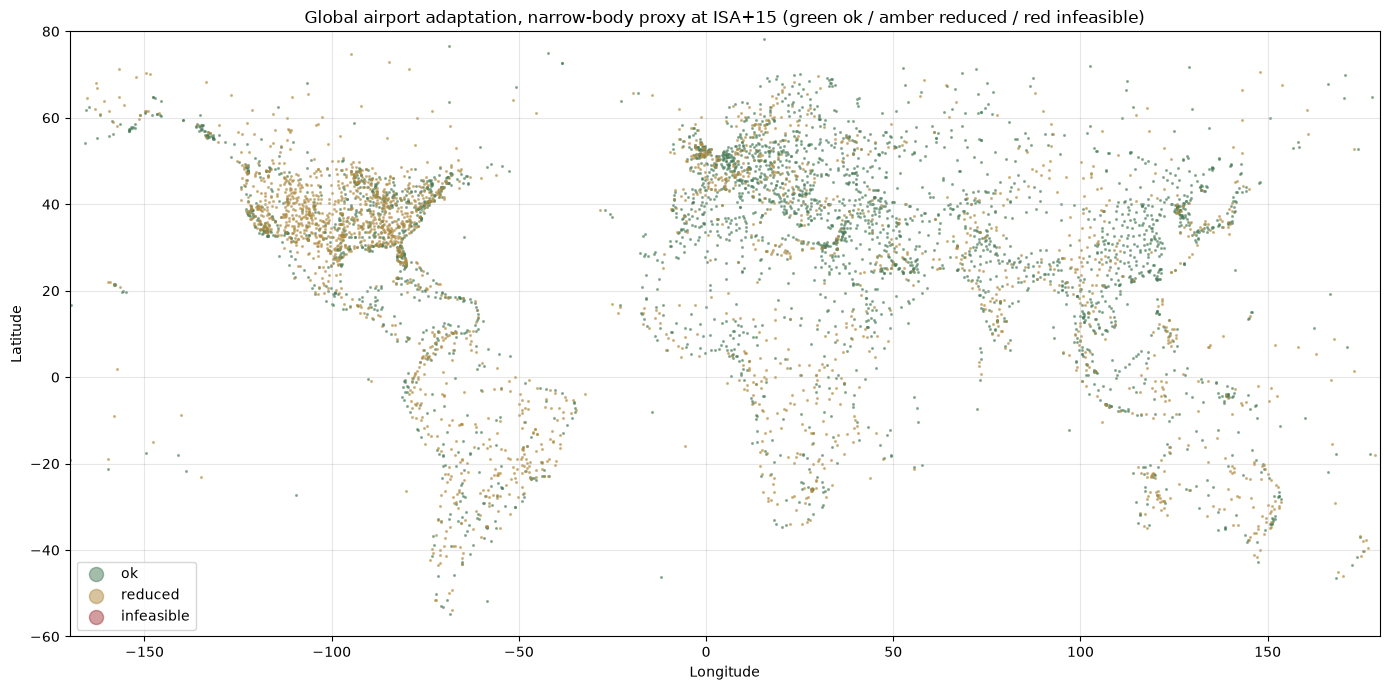

In [4]:
colors = {"ok": "#4a7c59", "reduced": "#b08a3e", "infeasible": "#a63d40"}
fig, ax = plt.subplots(figsize=(14, 7))
for verdict, color in colors.items():
    sub = scan_df[scan_df["verdict"] == verdict]
    ax.scatter(sub["lon_deg"], sub["lat_deg"], s=1.6, c=color, label=verdict, alpha=0.5)
ax.set_xlim(-170, 180)
ax.set_ylim(-60, 80)
ax.set_title("Global airport adaptation, narrow-body proxy at ISA+15 "
             + "(green ok / amber reduced / red infeasible)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=8, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**读数**：绿色覆盖北美/欧洲/东亚的成熟网络；红色集中在**高高原**（青藏高原、玻利维亚、
秘鲁安第斯——拉巴斯/库斯科是世界著名减载机场）与**短跑道**（非洲/东南亚部分支线）；
琥珀色的减载带横贯美国西部山区与中亚。这张图就是一张全球运力地图——
也是机型市场部做"这款飞机能飞哪里"演讲时的那页 PPT。

## 3. 温度情景：热天让哪些机场掉出可用名单？

In [5]:
hot = scan_region(db, AC, min_runway_m=1700.0, temp_c=None)          # ISA+15
hotter = scan_region(db, AC, min_runway_m=1700.0, temp_c=50.0)       # 极端热天 50 C
order = ["ok", "reduced", "infeasible"]
v1 = pd.Series([r.verdict for r in hot]).value_counts().reindex(order).fillna(0).astype(int)
v2 = pd.Series([r.verdict for r in hotter]).value_counts().reindex(order).fillna(0).astype(int)
scenario = pd.DataFrame({"ISA+15": v1, "50 C 极端热天": v2}).fillna(0).astype(int)
scenario.loc["覆盖率 %"] = [
    round(100 * (1 - scenario.loc["infeasible", c] / scenario[c].sum()), 1)
    for c in scenario.columns
]
scenario

,ISA+15,50 C 极端热天
ok,3430.0,2695.0
reduced,2420.0,3155.0
infeasible,0.0,0.0
覆盖率 %,100.0,100.0


**读数**：极端热天（50 °C）让一批琥珀色机场掉进红色——这就是"热天减载"的量级，
也是为什么沙漠机场（迪拜、凤凰城）的夏季航班常在深夜起降。

## 结论与局限

- 全球版图：绝大多数成熟干线机场满载可用；**高高原与短跑道**是天然的减载/不可用带；
- 中国高高原梯队（稻城/邦达/康定/阿里/玉树）的相对紧张度排序与真实运行一致；
- **局限**：启发式场长（基础值偏乐观，绝对余量偏大、相对排名可靠）、无障碍物/净空分析、
  着陆距离为 0.65×起飞粗估、温度为假设值。真实机场适配评估使用 AFM 性能图表与
  逐跑道分析。